In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import random

sns.set_palette('Set2')

# Блок numpy

## Магия чисел и линала
Используйте библиотеку <code>numpy</code> для задач в этом блоке  


### Задача 1  
1) Создайте одномерный массив размером 10, составленный из чисел от 1 до 10  
2) Преобразуйте его в двумерный массив размером 2х5  

In [10]:
q = np.arange(1, 11)
q.reshape((2, -1))

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

### Задача 2  
1) Создайте 2 массива одинаковой длины и найдите их сумму, разность, произведение  
2) Найдите среднее, медиану, дисперсию и стандартное отклонение  


In [32]:
a, b = np.random.randint(100, size=100), np.random.randint(100, size=100) 
absum = a + b
abdiff = a - b
abprod = a * b
print(a.mean(), np.median(a), a.var(), a.std())

49.66 47.0 813.9444 28.52971082923905


### Задача 3  
На вход дан одномерный массив $X$. Напишите функцию, которая выдает на вход массив из кумулятивных средних массива $X$. Иначе говоря, если $X = \left(x_1, x_2, \ldots, x_n\right)$, то ответ должен быть равен $s = \left(s_1, s_2, \ldots, s_n\right)$,  где $s_k=\frac{x_1+...+x_k}{k}$.

<details>
  <summary>Подсказка</summary>

Вам поможет функция <code>cumsum</code>  
Пример: [15, 7, 22, 11, 30, 5, 18] -> [15.0, 11.0, 14.66666667, 13.25, 15.0, 12.66666667, 13.71428571]
</details>

In [45]:
sample = [4, 23, 69, 90, 5, 45, 19, 21]
s = np.cumsum(sample, dtype = float)  # Compute cumulative sum

# Calculate running average
for i in range(len(s)):
    s[i] = s[i] / (i + 1)

print(s)

[ 4.         13.5        32.         46.5        38.2        39.33333333
 36.42857143 34.5       ]


### Задача 4  
Задан массив $X$. Для массива $X$ необходимо сделать следующее преобразование.

Необходимо написать функцию `transform`, которая построит новый массив, где все элементы с нечетными индексами требуется заменить на число 1. Все элементы с четными индексами нужно возвести в куб. Затем записать элементы в обратном порядке относительно их позиций.

Пример:
[3, 1, 4, -1, 2, 3, 0] -> [27, 1, 64, 1, 8, 1, 0] -> [0, 1, 8, 1, 64, 1, 27]

In [ ]:
sample = [56, 20, 12, 10, 6, 84, 39, 57]
def transform(x):
    for i in x[::2]

In [68]:
sample = [56, 20, 12, 10, 6, 84, 39, 57]
def transform(x):
    for i in range(len(x) // 2):
        x[2 * i + 1] = 1
        x[2 * i] **= 3
    x.reverse()
    return x
print(transform(sample))

[1, 59319, 1, 216, 1, 1728, 1, 175616]


### Задача 5  
Сгенерируйте два вектора `a` и `b` в трехмерном пространстве. Заполните их случайными числами. Реализуйте их скалярное произведение с помощью  `numpy`.


<details>
  <summary>Подсказка</summary>

  Для генерации можно использовать `np.random.sample`
</details>

In [76]:
# Генерация векторов
a = np.random.sample(3)
b = np.random.sample(3)

In [77]:
def no_numpy_scalar(v1, v2):
    """
    v1: list[n] --- первый вектор-аргумент длиной n
    v2: list[n] --- второй вектор-аргумент длиной n
    return c: float  --- результат скалярного произведения векторов v1 и v2

    Функция принимает на вход два вектора длиной n
    Возвращает число, равное их скалярному произведению v1 и v2

    Реализуйте скалярное умножение векторов, не используя функции из пакета numpy

    """
    result = sum(x * y for x, y in zip(v1, v2))
    return result

In [78]:
def numpy_scalar(v1, v2):
    """
    v1: np.array[n] --- первый вектор-аргумент длиной n
    v2: np.array[n] --- второй вектор-аргумент длиной n
    return c: float  --- результат скалярного произведения векторов v1 и v2

    Функция принимает на вход два вектора длиной n
    Возвращает число, равное их скалярному произведению

    Реализуйте скалярное умножение векторов, используя функции из пакета numpy
    """
    result = v1 @ v2
    return result

In [79]:
product_1 = no_numpy_scalar(a,b)
product_2 = numpy_scalar(a,b)

# проверим корректность:
assert np.allclose(product_1, product_2)

In [80]:
%time product_1 = no_numpy_scalar(a,b)
%time product_2 = numpy_scalar(a,b)

CPU times: total: 0 ns
Wall time: 0 ns
CPU times: total: 0 ns
Wall time: 0 ns


## Нео и матрицы

### Задача 6  
Для генерации матриц используем модуль random &mdash; он используется для генерации случайных объектов, функция sample создает случайную выборку. В качестве аргумента ей передается кортеж $\left(i,j\right)$, здесь i &mdash; число строк, j &mdash; число столбцов.  

Выведите размерность $\left(ранг\right)$ каждой матрицы с помощью функции `ndim`. Используйте функцию `shape`, что она вывела? Посмотрите на тип переменной, и сравните с типом объекта `numpy` созданной с помощью функции `matrix`

In [17]:
a = np.random.sample((100, 100))
b = np.random.sample((100, 100))

adim = np.ndim(a)
bdim = np.ndim(b)
ashape = np.shape(a)
bshape = np.shape(b)
print(adim, bdim, '\n', ashape, bshape)

c = np.matrix('1 2; 3 4')
print(type(a))

2 2 
 (100, 100) (100, 100)
<class 'numpy.ndarray'> <class 'numpy.matrix'>


### Задача 7  
Вам предлагается перемножить две квадратные матрицы двумя способами &mdash; без использования пакета `numpy` и с ним. Сравните время выполнения.

In [19]:
def no_numpy_mult(a, b):
    """
    A: list of "size" lists, each contains "size" floats --- первая матрица-аргумент
    B: list of "size" lists, each contains "size" floats --- вторая матрица-аргумент
    return C: list of "size" lists, each contains "size" floats --- матрица, являющаяся результатом умножения матриц a и b

    Функция принимает на вход две матрицы: A и B размерностью size x size
    Возвращает матрицу их произведения A * B = C

    """
    size = len(a)
    result = [[0] * size for _ in range(size)]
    for i in range(size):
        for j in range(size):
            for k in range(size):
                result[i][j] += a[i][k] * b[k][j]
    return result

In [20]:
def numpy_mult(a, b):
    """
    A: np.ndarray[size, size]              --- первая матрица-аргумент
    B: np.ndarray[size, size]              --- вторая матрица-аргумент
    return C: np.array[size, size]       --- матрица, являющаяся результатом умножения матриц A и B

    Функция принимает на вход две матрицы: A и B размерностью size x size
    Возвращает матрицу их произведения A * B = C

    Реализуйте умножение матриц, используя функции из пакета numpy
    """
    return a @ b

In [21]:
M1 = no_numpy_mult(a, b)
M2 = numpy_mult(a, b)

# проверим корректность
assert np.allclose(np.array(M1), M2)

In [22]:
%%time
# засечем время работы функции без NumPy
M1 = no_numpy_mult(a, b)

CPU times: total: 641 ms
Wall time: 660 ms


In [23]:
%%time
# засечем время работы функции с NumPy
M2 = numpy_mult(a, b)

CPU times: total: 0 ns
Wall time: 1.5 ms


### Задача 8  
Создайте случайно заполненную матрицу 5x5 и проведите следующие действия с ней:  
1) Транспонированние  
2) Нахождение детерминанта  
3) Нахождение обртаной матрицы    
4) Создайте и обедините 2 матрицы сначала по столбцу, а потом по строкам  
5) Разбейте исходную матрицу   

In [29]:
##YOUR CODE

matrix = np.random.random((5, 5))
transposed_matrix = np.transpose(matrix)
det = np.linalg.det(matrix)
inv_matrix = np.linalg.inv(matrix)

print("Исходная матрица:\n", matrix)
print("Транспонированная матрица:\n", transposed_matrix)
print("Определитель:\n", det)
print("Обратная матрица:\n", inv_matrix)

Исходная матрица:
 [[0.75758888 0.44621599 0.73625035 0.75665764 0.85400467]
 [0.64367301 0.7600247  0.78666024 0.92633479 0.59310024]
 [0.43139935 0.35348784 0.49655846 0.5884849  0.20821264]
 [0.85715135 0.77366199 0.39952674 0.03572372 0.47102625]
 [0.02768028 0.66857476 0.7758158  0.16433033 0.52798558]]
Транспонированная матрица:
 [[0.75758888 0.64367301 0.43139935 0.85715135 0.02768028]
 [0.44621599 0.7600247  0.35348784 0.77366199 0.66857476]
 [0.73625035 0.78666024 0.49655846 0.39952674 0.7758158 ]
 [0.75665764 0.92633479 0.5884849  0.03572372 0.16433033]
 [0.85400467 0.59310024 0.20821264 0.47102625 0.52798558]]
Определитель:
 -0.051294851833089315
Обратная матрица:
 [[ 0.53607951 -1.71566327  2.12479615  0.93147258 -0.60875064]
 [-1.73929235  3.03016626 -2.5461157   0.54558968 -0.07326361]
 [ 0.6053152  -3.91039133  4.94223716 -0.13716564  1.58694561]
 [-0.35240379  2.2811041  -1.15866659 -0.79158056 -0.82931177]
 [ 1.3945564   1.28883475 -3.78875479 -0.2917787  -0.05504661]]

In [43]:
##YOUR CODE
a, b = np.random.random((2, 2)), np.random.random((2, 2))

coancated_matrix_col = np.concatenate((a, b), axis = 0)
coancated_matrix_row = np.concatenate((a, b), axis = 1)
splited_matrix_col = np.split(a, 2, axis = 1)
splited_matrix_row = np.split(a, 2, axis = 0)

print("Первая матрица\n", a)
print("Вторая матрица\n", b)
print("Объединение по столбцу\n", coancated_matrix_col)
print("Объединение по строке\n", coancated_matrix_row)
print("Разбитая матрица по столбцу\n", splited_matrix_col)
print("Разбитая матрица по строке\n", splited_matrix_row)

Первая матрица
 [[0.55072221 0.01502441]
 [0.37924623 0.18395459]]
Вторая матрица
 [[0.84204939 0.79127904]
 [0.23967741 0.44820767]]
Объединение по столбцу
 [[0.55072221 0.01502441]
 [0.37924623 0.18395459]
 [0.84204939 0.79127904]
 [0.23967741 0.44820767]]
Объединение по строке
 [[0.55072221 0.01502441 0.84204939 0.79127904]
 [0.37924623 0.18395459 0.23967741 0.44820767]]
Разбитая матрица по столбцу
 [array([[0.55072221],
       [0.37924623]]), array([[0.01502441],
       [0.18395459]])]
Разбитая матрица по строке
 [array([[0.55072221, 0.01502441]]), array([[0.37924623, 0.18395459]])]


# Блок matplotlib/seaborn

## Давайте рисовать(matplotlib)

### Задача 1  
Нарисуйте график синусоидальной волны для диапазона значений от 0 до 2$\pi$. Добавьте заголовок, метки осей и сетку.

<details>
  <summary>Подсказка</summary>

  Используйте функции `np.linspace` для создания массива значений и `np.sin` для вычисления синуса.
</details>


In [57]:
x = np.linspace(0, 2*np.pi, 100)

In [58]:
y = np.sin(x)

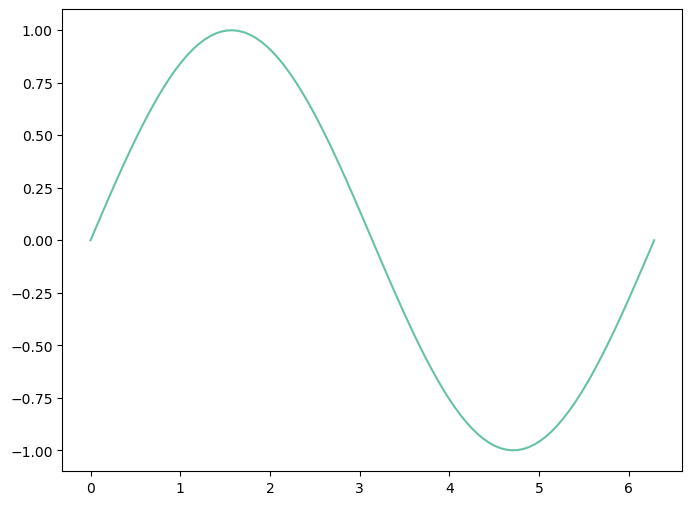

In [61]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(x, y)
plt.show()

### Задача 2  
Сгенерируйте 1000 случайных чисел из нормального распределения и постройте гистограмму их распределения. Добавьте линию нормального распределения поверх гистограммы.


<details>
  <summary>Подсказка</summary>

  Вспоните про правило 3$\sigma$  
  Нормальное распределение y = $\frac{1}{\sqrt{2\pi}} \cdot exp(-\frac{1}{2}(\frac{x - \mu}{\sigma})^2)$
</details>


In [114]:
# Генерация 1000 случайных чисел из нормального распределения

a = np.random.normal(size = 1000, loc = 0, scale = 1)

In [115]:
# Добавление линии нормального распределения
mu, std = 0, 1 # среднее и стандартное отклонение
x = np.linspace(-4, 4, 1000)
y = 1/np.sqrt(2*np.pi*std)*np.exp(-1/2 * np.power((x - mu)/(std), 2)) # линия нормального распределения

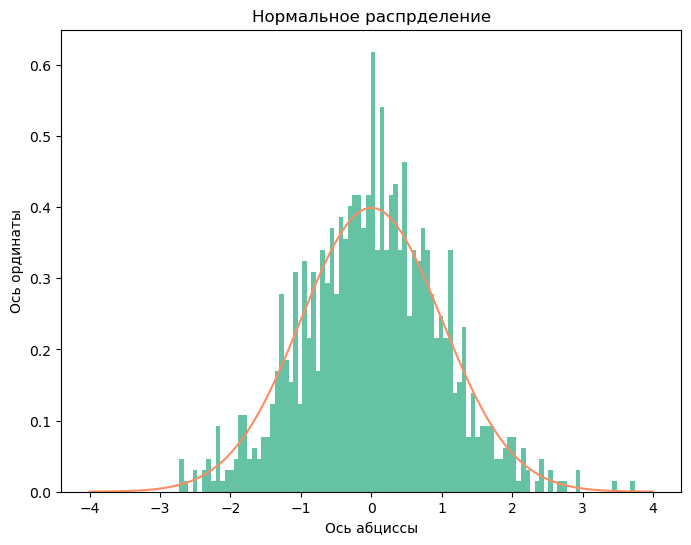

In [116]:
# Построение гистограммы

plt.figure(figsize = (8, 6))
plt.xlabel('Ось абциссы')
plt.ylabel('Ось ординаты')
plt.title('Нормальное распрделение')
plt.hist(a, bins = 100, density = True)
plt.plot(x, y)

### Задача 3  
Создайте массив sizes, который будет состоять из $10^2, 10^3, 10^4, 10^5$. Числа должны быть целыми.  

Постройте `plt.subplots` в виде строки из 4 графиков. Параметр `bins` укажите 100. На каждом графике отрисуйте гистограмму массива заданного размера из массива sizes. Подпишите, какой размер массивы к какому графику относится.

<details>
  <summary>Подсказка</summary>

 Для создания массива можно воспользоваться `np.logspace`  
 Подписи осей создаются как `axs[i].set('параметры')`
</details>

In [ ]:
sizes = [100, 1000, 10000, 100000]

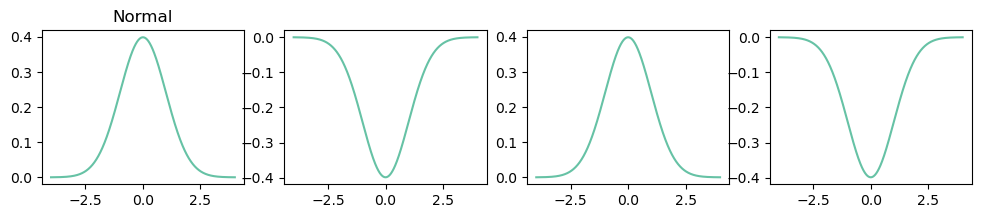

In [127]:
fig, axs = plt.subplots(figsize=(12, 2), ncols=4)

axs[0].plot(x, y)
axs[1].plot(x, -y)
axs[2].plot(x, y)
axs[3].plot(x, -y)

axs[0].set_title('Normal')
plt.show()

На какое распределение похоже?

### Задача 4  
Создайте анимацию, показывающую распространение волны в двумерной плоскости. Волна должна начинаться из центра и распространяться во все стороны. Используйте цветовую карту для визуализации амплитуды волны.  

Требования:

1) Используйте библиотеку Matplotlib для создания анимации.  
2) Волна должна быть синусоидальной.  
3) Анимация должна показывать распространение волны от центра к краям.  
4) Используйте цветовую карту для визуализации амплитуды волны.  
5) Добавьте заголовок и цветовую шкалу.  

<details>
  <summary>Подсказка</summary>

Используйте `numpy.meshgrid` для создания сетки координат.  
Используйте `matplotlib.animation.FuncAnimation` для создания анимации.  
Используйте `matplotlib.pyplot.imshow` или `matplotlib.pyplot.pcolormesh` для визуализации волны.  
</details>


Для начала построим статическую картину распределения

In [4]:
# Параметры волны
size = 1000 # размер сетки
amplitude = 5 # амплитуда волны
frequency = 1 # частота волны

In [5]:
# Создаем сетку координат
x = np.linspace(-10, 10, size)
y = np.linspace(-10, 10, size)
X, Y = np.meshgrid(x, y)

# Функция волны
Z =  amplitude * np.sin(X ** 2 + Y ** 2)

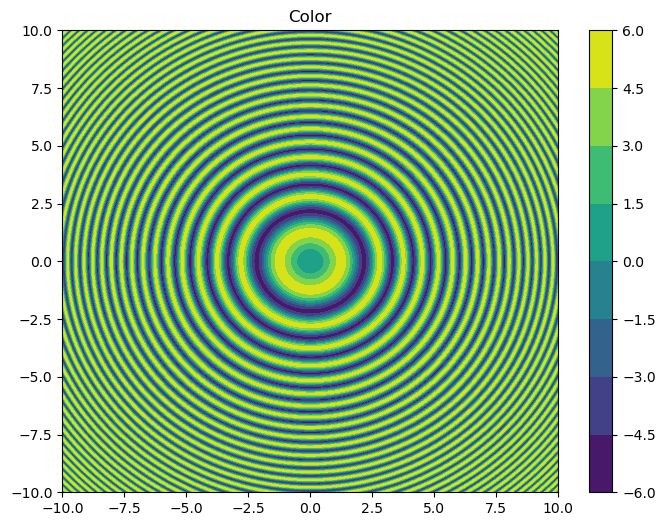

In [6]:
# Построение статического изображения

plt.figure(figsize = (8, 6))
plt.contourf(X, Y, Z)
plt.colorbar()
plt.title('Color')
plt.show()

Теперь изменим функцию так, чтобы она обновлялась покадрово  

<details>
  <summary>Подсказка</summary>

Синус зависит от `frames`
</details>

In [24]:
# Параметры волны
frames = 100 # количество кадров

In [25]:
# Функция для обновления анимации
def update(frame):
    Z = 5 * np.sin(X ** 2 + Y ** 2 + frame * 0.2)
    cax.set_array(Z)
    ax.set_title(f'Frame {frame}')
    return cax,

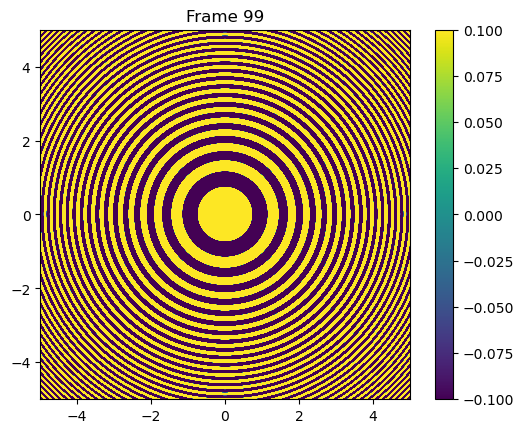

In [26]:
import matplotlib.animation as animation
from IPython.display import HTML

# Создаем фигуру и оси
fig, ax = plt.subplots()
cax = ax.imshow(np.zeros((size, size)), cmap='viridis', extent=(-5, 5, -5, 5), animated=True)
fig.colorbar(cax, ax=ax)

# Создаем анимацию
ani = animation.FuncAnimation(fig=fig, func=update, frames=frames, interval=50, blit=True)

# Отображаем анимацию в Colab
HTML(ani.to_jshtml())


### Задача 5  

Сгенерируйте набор данных, следующих нормальному распределению, и визуализируйте его с помощью гистограммы. Добавьте на тот же график линии, представляющие истинную плотность распределения и оценку плотности с использованием метода ядерной оценки плотности $\left(KDE\right)$.  

<details>
  <summary>Подсказка</summary>

Используйте `sns.histplot` для построения гистограммы.  
Используйте параметр `kde` в histplot для построения KDE.
</details>

In [127]:
# Параметры произвольного распределения
num_samples = 10000
loc1 = 0
loc2 = 5
scale1 = 1
scale2 = 2

In [128]:
# Генерация данных из произвольного распределения
# Например, смесь нормальных распределений
data1 = np.random.normal(loc=loc1, scale=scale1, size=num_samples // 2)
data2 = np.random.normal(loc=loc2, scale=scale2, size=num_samples // 2)
data = np.concatenate((data1, data2))


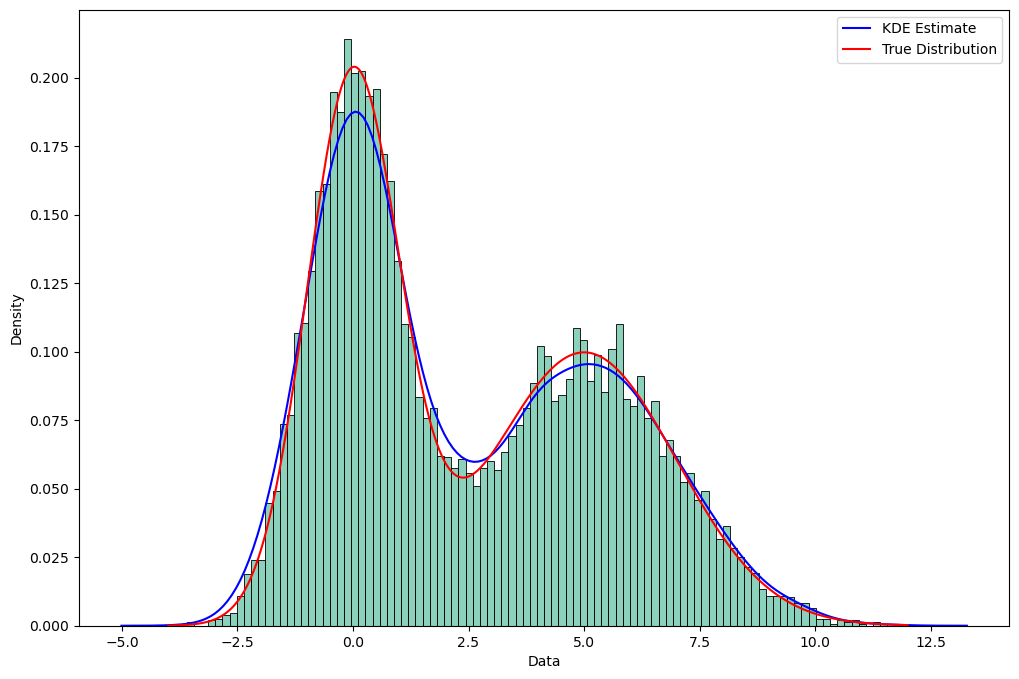

In [129]:
# Построение графика
plt.figure(figsize=(12, 8))
sns.histplot(data, bins=100, stat='density')  # Меняем цвет KDE и добавляем в легенду
sns.kdeplot(data, color = 'blue', label = 'KDE Estimate')

# Теоретическая кривая плотности смеси
x = np.linspace(-4, 12, 1000)
y1 = (1 / (np.sqrt(2 * np.pi) * scale1)) * np.exp(-0.5 * ((x - loc1) / scale1) ** 2)
y2 = (1 / (np.sqrt(2 * np.pi) * scale2)) * np.exp(-0.5 * ((x - loc2) / scale2) ** 2)
y = 0.5 * y1 + 0.5 * y2  # Смесь двух распределений

# Добавляем линию истинного распределения
sns.lineplot(x=x, y=y, color='red', label='True Distribution')

plt.xlabel('Data')
plt.show()


Можно ли построить истинную плотность? Что показывает ЯОП (ядерная оценка плотности)?

## Море фантазии

### Задача 6  
Создайте тепловую карту корреляции для набора данных, содержащего информацию о различных характеристиках автомобилей (например, цена, мощность двигателя, расход топлива и т.д.). Визуализация должна показывать, как различные характеристики коррелируют друг с другом.

Требования:

1) Используйте библиотеку Seaborn для создания тепловой карты корреляции.  
2) Добавьте аннотации к каждой ячейке тепловой карты, показывающие значения корреляции.  
3) Используйте цветовую шкалу для визуализации корреляции.  
4) Добавьте заголовок и метки осей.   

<details>
  <summary>Подсказка</summary>

Используйте `pandas.DataFrame.corr` для вычисления матрицы корреляции.  
Используйте `seaborn.heatmap` для создания тепловой карты корреляции.  
</details>


In [4]:
# Загрузка набора данных
data = sns.load_dataset('mpg')
# Удаление категориальных переменных
data = data.select_dtypes(include=['float64', 'int64'])

In [5]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [195]:
# Вычисление матрицы корреляции
a = data.corr(numeric_only=True)

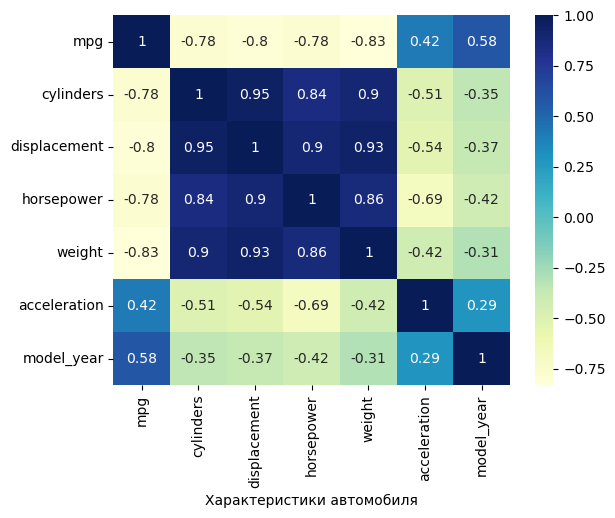

In [11]:
# Создание тепловой карты корреляции
dataplot = sns.heatmap(a, cmap = "YlGnBu", annot = True)
plt.xlabel('Характеристики автомобиля')
plt.show()

### Задача 7  

Сгенерируйте набор данных, содержащий две переменные, и визуализируйте их с помощью scatter plot. Добавьте линию регрессии на график.  

<details>
  <summary>Подсказка</summary>

Используйте `numpy.random.normal` для генерации данных.
Используйте `seaborn.scatterplot` для построения scatter plot.
Используйте `seaborn.regplot` для добавления линии регрессии.  
</details>

In [15]:
# Генерация данных

size = 100
x = np.linspace(0, 10, size)

In [20]:
y = 2 * x + np.random.normal(loc=0, scale=1, size=size) # зависимая (предсказываемая) переменная

In [22]:
from sklearn.linear_model import LinearRegression

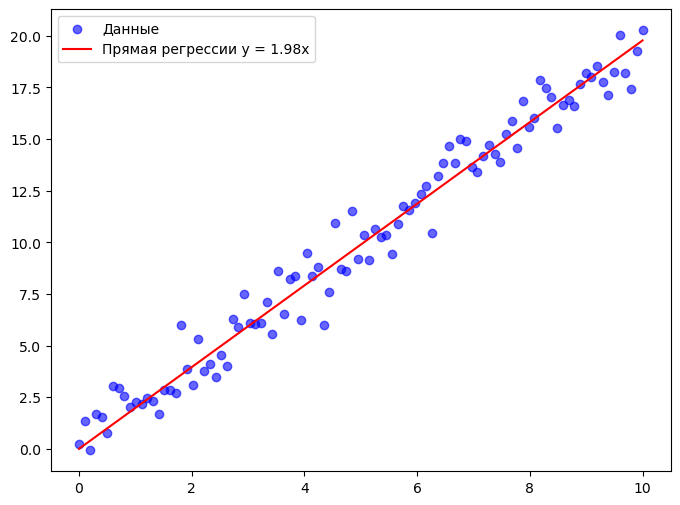

In [35]:
#Построение scatter plot и линии регрессии

plt.figure(figsize=(8, 6))
plt.scatter(x, y, label = 'Данные', color = 'blue', alpha = 0.6)
x_reshaped = x.reshape(-1, 1)
reg = LinearRegression(fit_intercept=False).fit(x_reshaped, y)
slope = reg.coef_[0]
intercept = reg.intercept_
y_pred = reg.predict(x_reshaped)
plt.plot(x, y_pred, color = 'r', label = f'Прямая регрессии y = {slope:.2f}x')
plt.legend()
plt.show()

# Блок Pandas

## Series Sam

### Задача 1  
Это структура данных, которую можно рассматривать как одну колонку таблицы, одномерный массив.

Создайте объект Series на основе имеющихся данных и выведите месяц своего рождения, а так же промежуток месяцев, когда бы вы хотели родиться (месяца должны быть последовательны):

<details>
  <summary>Подсказка</summary>

Можно воспользоваться методами `.loc` или `.iloc`
</details>

In [41]:
# Полный список месяцев
months = [
    "Январь", "Февраль", "Март", "Апрель", "Май", "Июнь",
    "Июль", "Август", "Сентябрь", "Октябрь", "Ноябрь", "Декабрь"
]

# Полный список индексов
indexes = [
    "Первый", "Второй", "Третий", "Четвёртый", "Пятый", "Шестой",
    "Седьмой", "Восьмой", "Девятый", "Десятый", "Одиннадцатый", "Двенадцатый"
]

# Создание Series
df = pd.Series(data = months, index = indexes)
print(df['Второй'])
print(df[1:4])

Февраль
Второй       Февраль
Третий          Март
Четвёртый     Апрель
dtype: object


### Задача 2  

1) Создайте Series с числовыми данными (случайным образом в диапазоне от 1 до 100)

2) Вычислите среднее значение, сумму и максимальное значение

In [44]:
df = pd.Series(np.random.uniform(size=100, low = 1, high = 100))

In [48]:
print(df.mean(), df.max(), df.sum())

49.30808844145389 98.1379028303127 4930.808844145389


### Задача 3  
1) Создайте Series с числовыми данными  (случайным образом в диапазоне от 1 до 100)    

2) Отфильтруйте значения, которые больше заданного порога (например 30)

In [58]:
df = pd.Series(data = np.random.uniform(size = 100, low = 1, high = 100))
edge = 30
print(df[df>30])

0     61.903302
2     33.875708
4     76.465386
6     68.136431
7     78.477938
        ...    
95    47.246694
96    85.844298
97    40.748397
98    54.515858
99    57.798358
Length: 75, dtype: float64


### Задача 4  
Создайте Series с числовыми данными  (случайным образом в диапазоне от 1 до 100) и примените функцию для преобразования значений (например, умножение на 2)

<details>
  <summary>Подсказка</summary>

Используйте метод `apply()` для применения функции. Однако он работает медленнее, чем векторизированные операции, поэтому им стоит пользоваться только в крайних случаях
</details>

In [87]:
# Создание объекта Series

df = pd.Series(np.random.uniform(size=100, low=1, high=100))
print(df.apply(lambda x: x * 2))

0     162.005131
1     147.102822
2      73.171715
3     123.776629
4       6.756009
         ...    
95    156.547666
96    171.566223
97    142.209046
98     10.985835
99     91.917223
Length: 100, dtype: float64


In [93]:
# Функция для сложного преобразования с использованием apply
def apply_complex_transform(series):
    """
    Применяет сложное преобразование к каждому элементу Series с использованием метода apply.

    Parameters:
    series (pd.Series): Входная Series с числовыми данными.

    Returns:
    pd.Series: Преобразованная Series.
    """
    def complex_transform(x):
        return x * 2
    return series.apply(complex_transform)

# Функция для векторизированной операции
def vectorized_operation(series):
    """
    Выполняет векторизированную операцию умножения всех элементов Series на 2.

    Parameters:
    series (pd.Series): Входная Series с числовыми данными.

    Returns:
    pd.Series: Преобразованная Series.
    """
    return series * 2

In [94]:
# Результаты преобразований

print (apply_complex_transform(df))
print(vectorized_operation(df))

0     162.005131
1     147.102822
2      73.171715
3     123.776629
4       6.756009
         ...    
95    156.547666
96    171.566223
97    142.209046
98     10.985835
99     91.917223
Length: 100, dtype: float64
0     162.005131
1     147.102822
2      73.171715
3     123.776629
4       6.756009
         ...    
95    156.547666
96    171.566223
97    142.209046
98     10.985835
99     91.917223
Length: 100, dtype: float64


In [97]:
%%time
# Пример кода
result = sum(range(1000000))


CPU times: total: 46.9 ms
Wall time: 31.2 ms


In [103]:
%%time
transformed_series_apply = apply_complex_transform(df)

CPU times: total: 0 ns
Wall time: 496 μs


In [105]:
%%time
transformed_series_vectorized = vectorized_operation(df)

CPU times: total: 0 ns
Wall time: 0 ns


### Задача 5  

У вас есть два объекта Series, содержащих данные о продажах за два разных месяца. Объедините эти данные и визуализируйте их с помощью линейного графика, чтобы показать изменение продаж по дням.  

<details>
  <summary>Подсказка</summary>

Для улучшения визуализации можно воспользоваться `plt.xticks`
Для объединения даты можно воспользоваться `pd.concat`
</details>

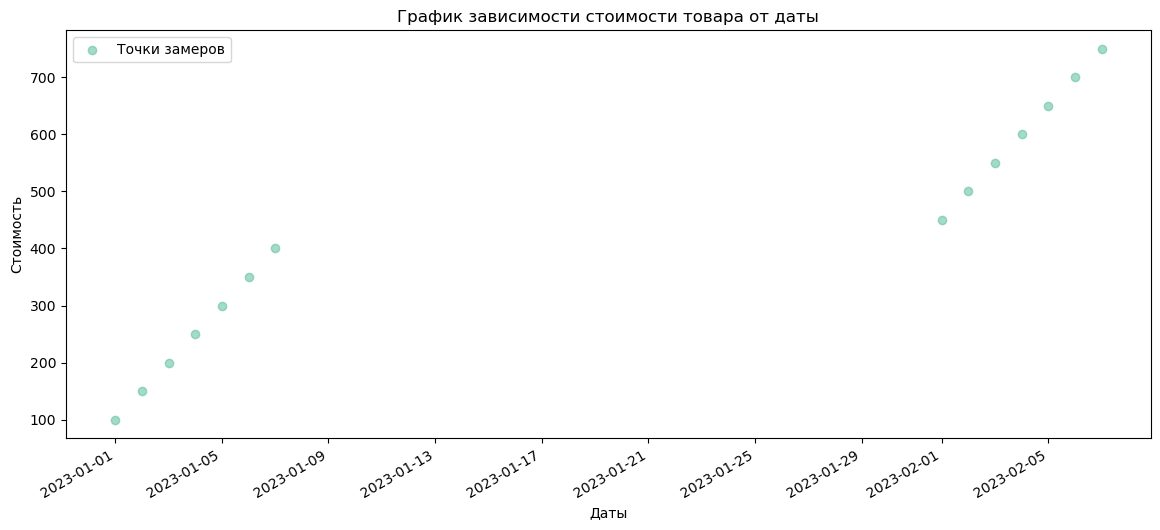

In [131]:
# Создание данных о продажах за первый месяц
sales_january = pd.Series([100, 150, 200, 250, 300, 350, 400],
                          index=pd.date_range(start='2023-01-01', periods=7, freq='D'))

# Создание данных о продажах за второй месяц
sales_february = pd.Series([450, 500, 550, 600, 650, 700, 750],
                           index=pd.date_range(start='2023-02-01', periods=7, freq='D'))

# Объединение данных
sales_jan_feb = pd.concat([sales_january, sales_february])

y = sales_jan_feb.values
x = sales_jan_feb.index
fig, ax = plt.subplots(figsize = (14,6))
plt.scatter(x, y, label = 'Точки замеров', alpha = 0.6)
fig.autofmt_xdate()
ax.set_xlabel('Даты')
ax.set_ylabel('Стоимость')
ax.set_title('График зависимости стоимости товара от даты')
plt.legend()
plt.show()

## 🐼🐼🐼

### Задача 6  
Объект **DataFrame** лучше всего объяснять на примере обычной таблицы. В таблице есть строки и столбцы. Столбцами в объекте **DataFrame** выступают объекты **Series**, а их элементы будут строками.

Создайте **DataFrame** (проще всего из словаря, в котором ключ это название колонки, значения &mdash; данные массива)  

Данные могут быть как текстового так и числового, созданный объект в этом задании можно использовать в 7, тогда лучше создать объект с числовыми данными

In [140]:
df = pd.DataFrame.from_dict(data={'Name': ['Kirill', 'Danil', 'Dima', 'Ivan'], 'Age': [16, 11, 18, 12]})
print(df)

     Name  Age
0  Kirill   16
1   Danil   11
2    Dima   18
3    Ivan   12


### Задача 7  
Повторите задания 2&mdash;4 из этого блока, но только для объекта Dataframe, с соответвующими методами  

In [148]:
print(df['Age'].mean(), df['Age'].sum(), df['Age'].max())
edge = 14
print(df[df['Age'] > edge])
print(df['Age'] - 1)

14.25 57 18
     Name  Age
0  Kirill   16
2    Dima   18
0    15
1    10
2    17
3    11
Name: Age, dtype: int64


### Задача 8  
У вас есть DataFrame, содержащий данные о продажах различных товаров в нескольких категориях. Вычислите общую сумму продаж для каждой категории и визуализируйте результаты с помощью столбчатой диаграммы.  

<details>
  <summary>Подсказка</summary>

Используйте метод `groupby()` для применения функции.
</details>

[]

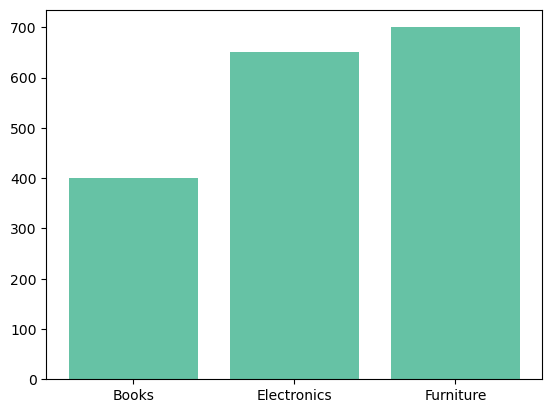

In [187]:
data = pd.DataFrame({
    'Category': ['Electronics', 'Books', 'Electronics', 'Books', 'Furniture', 'Electronics', 'Furniture'],
    'Sales': [100, 150, 200, 250, 300, 350, 400]
})
d = data.groupby('Category').sum().reset_index()
plt.bar(x=d['Category'], height=d['Sales'])
plt.plot()

### Задача 9  

У вас есть два DataFrame, содержащих данные о продажах и клиентах. Объедините эти данные по общему ключу и визуализируйте распределение продаж по возрасту клиентов.  

<BarContainer object of 5 artists>

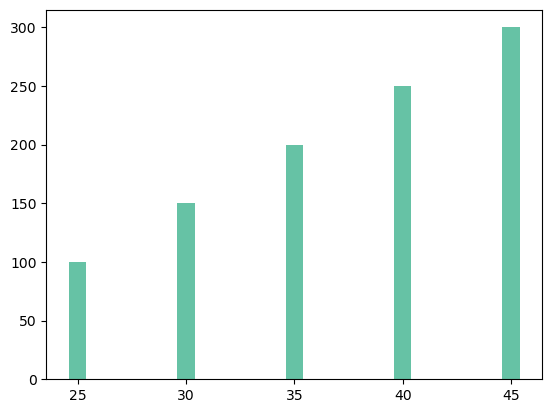

In [193]:
# Создание DataFrame с данными о продажах
sales_data = pd.DataFrame({
    'ClientID': [1, 2, 3, 4, 5],
    'Sales': [100, 150, 200, 250, 300]
})

# Создание DataFrame с данными о клиентах
clients_data = pd.DataFrame({
    'ClientID': [1, 2, 3, 4, 5],
    'Age': [25, 30, 35, 40, 45]
})

data = sales_data.merge(clients_data, on = 'ClientID')
plt.bar(x = data['Age'], height = data['Sales'])

### Задача 10  

У вас есть DataFrame, содержащий данные о различных характеристиках автомобилей. Вычислите корреляционную матрицу и визуализируйте её с помощью тепловой карты

In [196]:
# Создание DataFrame с данными о характеристиках автомобилей
np.random.seed(0)  # Для воспроизводимости результатов
data = pd.DataFrame({
    'Price': np.random.randint(20000, 50000, size=100),
    'Mileage': np.random.randint(1000, 50000, size=100),
    'Horsepower': np.random.randint(100, 400, size=100),
    'FuelEfficiency': np.random.randint(15, 40, size=100),
    'Age': np.random.randint(1, 10, size=100)
})

a = data.corr(numeric_only = True)
sns.heatmap(a, )

Что можно сказать исходя из полученного рисунка?

# Оставь надежду всяк сюда входящий (необязательные усложненные задачи)

### Задача 1  
Напишите функцию `encode_rle(x)`, реализующую кодирование длин серий (Run&mdash;length encoding). По входному вектору x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй &mdash; сколько раз их нужно повторить.

In [ ]:
def encode_rle(x):
    pass

### Задача 2  
Даны матрицы $A$ размера $(n \times d)$ и $B$ размера $(m \times d)$. Напишите функцию `find_equal_lines(A, B)`, которая найдет в $A$ все строки, содержащиеся в $B$.

In [ ]:
def find_equal_lines(A, B):
    pass

In [ ]:
A = np.array([
    [1, 2, 3],
    [1, 2, 1],
    [4, 5, 6],
    [1, 2, 1],
])
B = np.array([
    [4, 5, 6],
    [4, 5, 6],
    [1, 2, 3],
])
indices = find_equal_lines(A, B)

assert (indices == [0, 2]).all()

A = np.array([
    [0, 1],
    [0, 3],
    [0, 2],
    [1, 1],
    [0, 1],
])
B = np.array([
    [0, 1],
    [1, 1],
])
indices = find_equal_lines(A, B)

assert (indices == [0, 3, 4]).all()

Решение (потом удалить)

In [ ]:
def find_equal_lines(A, B):
    match_by_rows = np.all(A[:, None] == B, axis=2)
    match_ind_of_A = np.any(match_by_rows, axis=1)
    return np.where(match_ind_of_A)[0]

### Задача 3  
Группа шахтёров отправилась в богатую золотом шахту размером $H \times W$. В каждом квадратном участке шахты содержится определённое количество золота $(в\ граммах).$

Шахтёры могут выбрать прямоугольную рабочую область размером $h \times w$ с вероятностным распределением $Q$. Чтобы добыча была максимально эффективной, необходимо понять, сколько золота можно получить, если начать разработку в каждой возможной позиции прямоугольного участка.

Ваша задача — вычислить сумму золота для каждой возможной рабочей области размером $h \times w$ в шахте.

Необходимо написать функцию `calc_expectations(h, w, X, Q)`, где:

* $h$, $w$ &mdash; размеры рабочего участка;
* $X$ &mdash; матрица целых чисел размера $H$ на $W$; $X[i, j]$ содержит количество золота в клетке $(i, j)$;
* $Q$ &mdash; матрица вещественных чисел размера $H$ на $W$, задающая вероятностное распределение; $Q[i, j]$ &mdash; вероятность начала разработки шахты в точке $i$, $j$.
Функция возвращает матрицу $E$ размера $H$ на $W$; $E[i, j]$ &mdash; математическое ожидание общего числа золота в $i$, $j$ клетке.


In [ ]:
def calc_expectations(h, w, X, Q):
    pass

In [ ]:
assert np.isclose(calc_expectations(
    h=3, w=2,
    X=np.array([[1, 7, 7, 3, 9, 9, 1, 6, 5, 4, 2, 8, 1],
       [4, 2, 3, 3, 5, 2, 9, 8, 1, 6, 4, 0, 8],
       [7, 0, 1, 0, 2, 5, 8, 6, 6, 1, 2, 5, 3],
       [6, 6, 4, 7, 5, 6, 3, 6, 3, 7, 6, 3, 0],
       [5, 0, 1, 2, 3, 1, 6, 5, 7, 6, 6, 7, 4],
       [7, 5, 0, 7, 0, 7, 7, 6, 8, 2, 2, 1, 0],
       [7, 9, 3, 4, 3, 1, 8, 1, 2, 4, 4, 8, 5],
       [8, 9, 7, 2, 3, 3, 5, 2, 6, 6, 3, 4, 0],
       [0, 6, 1, 4, 7, 7, 4, 3, 0, 6, 4, 7, 0],
       [0, 1, 2, 3, 3, 2, 4, 2, 9, 0, 0, 7, 1],
       [3, 9, 6, 8, 8, 8, 4, 1, 4, 1, 3, 7, 8],
       [9, 3, 9, 8, 6, 8, 5, 6, 8, 8, 7, 3, 7],
       [8, 1, 6, 5, 4, 2, 2, 2, 4, 7, 5, 3, 0],
       [3, 6, 5, 1, 9, 4, 1, 6, 1, 5, 1, 0, 4],
       [9, 9, 3, 9, 7, 2, 1, 6, 2, 0, 3, 1, 2]]),
    Q=np.array([[7.06128335e-03, 4.32854712e-03, 4.97282659e-03, 4.28975248e-04,
        1.52144978e-02, 1.14482542e-02, 2.43938459e-04, 4.80466426e-03,
        9.64372202e-03, 7.03184347e-04, 3.84977818e-03, 1.05776223e-02,
        5.14362886e-03],
       [9.24436313e-03, 2.98413494e-03, 3.81136898e-03, 1.27570431e-04,
        1.60259127e-03, 9.37890642e-03, 1.61064289e-03, 7.28946679e-03,
        1.01010935e-03, 2.15836495e-03, 1.31738567e-05, 1.14783479e-02,
        9.97960200e-03],
       [1.67218293e-04, 4.16501424e-04, 5.28334039e-03, 4.02056616e-03,
        3.00437192e-03, 1.03583698e-03, 2.27912907e-03, 2.88989768e-04,
        6.18067342e-04, 5.58853705e-03, 3.04100386e-03, 3.77874165e-03,
        1.33713333e-02],
       [2.45054020e-03, 1.48131719e-02, 9.37826740e-03, 4.01778158e-03,
        5.62975005e-03, 1.23175453e-03, 1.92210924e-03, 6.50115831e-04,
        2.58719085e-03, 8.82945015e-03, 4.16173256e-03, 1.11269840e-03,
        1.80684370e-02],
       [1.09214591e-02, 2.02144550e-04, 3.70331471e-03, 3.21898170e-03,
        1.32230961e-03, 3.38907853e-04, 2.86048746e-02, 6.57763115e-03,
        1.03342216e-02, 3.36307060e-03, 1.39462107e-03, 1.51722255e-03,
        4.77644269e-03],
       [1.24691673e-02, 1.14883425e-04, 2.34377535e-03, 1.01890955e-02,
        5.34093343e-04, 1.22731966e-02, 2.95428821e-05, 2.06061711e-02,
        9.88025717e-03, 1.12686415e-02, 2.65915247e-03, 3.21341448e-03,
        7.17936871e-03],
       [2.13617503e-03, 5.71984734e-03, 2.79848540e-03, 3.40777682e-03,
        1.15609179e-02, 3.91498088e-05, 1.80787329e-03, 1.03214913e-02,
        7.73538022e-03, 1.11142219e-02, 2.40040379e-02, 8.42967363e-03,
        9.26405047e-04],
       [6.90240005e-03, 8.16304951e-03, 6.25103891e-03, 1.41531521e-03,
        7.89217265e-04, 1.24966032e-03, 3.14008357e-04, 7.66669841e-04,
        6.56264219e-03, 7.81723070e-03, 3.06695412e-03, 5.11854896e-04,
        5.06722512e-03],
       [2.70175496e-03, 9.20090175e-03, 6.10387733e-03, 1.02609252e-03,
        1.86663943e-02, 2.08808201e-03, 8.71209671e-03, 2.18200558e-02,
        7.60681873e-03, 4.67633850e-03, 4.65817470e-03, 9.21299105e-04,
        1.39679240e-02],
       [2.58766787e-03, 6.52264534e-03, 9.65563514e-03, 3.60784283e-03,
        8.79132503e-04, 2.09843044e-02, 3.17645988e-02, 2.04132132e-03,
        2.85657713e-04, 1.83877515e-04, 9.11058226e-04, 8.90937467e-04,
        3.88812912e-03],
       [7.22181563e-04, 4.19326167e-03, 4.95612899e-03, 3.09710053e-03,
        7.22291467e-03, 8.10639226e-03, 6.08628598e-04, 1.40044281e-02,
        1.61217102e-03, 2.98495531e-03, 1.41543605e-03, 1.93246291e-03,
        1.58283598e-02],
       [3.50661973e-03, 1.59955713e-03, 1.82168727e-03, 2.46812348e-03,
        2.58454429e-03, 2.48769676e-03, 4.61508131e-03, 1.24920430e-03,
        6.66907801e-04, 1.78574112e-03, 1.37351482e-04, 9.51255891e-04,
        3.20192712e-03],
       [8.72525597e-03, 2.63267794e-03, 4.05495868e-03, 9.03072585e-04,
        2.91856530e-03, 2.92281946e-03, 1.56003992e-03, 1.58268947e-03,
        8.33970186e-04, 8.88024788e-03, 1.66234524e-03, 4.09011375e-03,
        3.33138968e-03],
       [7.77890419e-03, 1.30059099e-03, 6.20490348e-03, 1.56875193e-02,
        5.03494568e-04, 2.19313582e-03, 1.12671022e-02, 3.33937831e-03,
        1.15536395e-02, 2.49040352e-03, 3.04110068e-03, 7.23072815e-05,
        3.23531924e-04],
       [6.21812399e-06, 1.99343356e-03, 1.15646432e-03, 3.78298926e-03,
        1.95689674e-03, 9.06572986e-03, 5.81139437e-03, 2.37368024e-03,
        6.48178061e-04, 6.13076244e-03, 1.85840964e-04, 1.01424413e-03,
        1.11364064e-02]])
), np.array([[0.00706, 0.07973, 0.06511, 0.01621, 0.14079, 0.23996, 0.01169,
        0.03029, 0.07224, 0.04139, 0.00911, 0.11542, 0.01572],
       [0.06522, 0.04724, 0.04829, 0.02802, 0.08687, 0.07529, 0.20414,
        0.11159, 0.02275, 0.08109, 0.0269 , 0.     , 0.29743],
       [0.11531, 0.     , 0.0218 , 0.     , 0.0488 , 0.20842, 0.20797,
        0.0991 , 0.14193, 0.01972, 0.03071, 0.16369, 0.16299],
       [0.07117, 0.18046, 0.14675, 0.18647, 0.09201, 0.1313 , 0.05238,
        0.08424, 0.03733, 0.14554, 0.14275, 0.07076, 0.     ],
       [0.0677 , 0.     , 0.0338 , 0.05924, 0.06364, 0.01256, 0.21248,
        0.20161, 0.14739, 0.18792, 0.15827, 0.10504, 0.1705 ],
       [0.18089, 0.20486, 0.     , 0.22996, 0.     , 0.14931, 0.3108 ,
        0.35034, 0.40508, 0.09253, 0.06335, 0.01406, 0.     ],
       [0.17869, 0.28407, 0.04465, 0.10265, 0.0907 , 0.02607, 0.34475,
        0.06795, 0.13091, 0.21478, 0.21521, 0.32974, 0.13021],
       [0.17206, 0.31955, 0.17774, 0.05281, 0.08369, 0.07934, 0.07857,
        0.06769, 0.33524, 0.32627, 0.17979, 0.16754, 0.     ],
       [0.     , 0.20894, 0.03824, 0.08401, 0.25806, 0.24075, 0.05684,
        0.13123, 0.     , 0.27308, 0.22135, 0.29114, 0.     ],
       [0.     , 0.03608, 0.09179, 0.08418, 0.07915, 0.08931, 0.26045,
        0.13084, 0.35175, 0.     , 0.     , 0.07672, 0.02525],
       [0.01803, 0.23336, 0.24379, 0.22757, 0.276  , 0.46358, 0.28906,
        0.07895, 0.18948, 0.01735, 0.04449, 0.07511, 0.29943],
       [0.06135, 0.0574 , 0.25874, 0.20485, 0.11916, 0.33812, 0.34283,
        0.3257 , 0.15888, 0.06015, 0.05193, 0.01872, 0.18685],
       [0.10363, 0.02138, 0.11555, 0.08651, 0.07678, 0.05249, 0.0406 ,
        0.04724, 0.0798 , 0.11735, 0.08433, 0.03057, 0.     ],
       [0.06003, 0.15326, 0.08807, 0.03114, 0.22559, 0.05444, 0.02505,
        0.14168, 0.01923, 0.13105, 0.018  , 0.     , 0.04788],
       [0.14859, 0.20193, 0.05203, 0.28611, 0.18027, 0.03912, 0.03282,
        0.15561, 0.04066, 0.     , 0.06717, 0.01007, 0.03994]]),
atol=1e-5).all()
assert np.isclose(calc_expectations(
    h=3, w=3,
    X=np.array([[2, 7, 9, 0, 2, 5, 5, 7, 3, 4, 2, 5],
       [6, 1, 0, 5, 2, 3, 3, 5, 8, 6, 6, 5],
       [1, 3, 2, 4, 5, 7, 2, 2, 8, 9, 6, 0],
       [6, 6, 8, 4, 3, 6, 2, 1, 9, 1, 7, 8],
       [5, 2, 1, 0, 3, 6, 3, 5, 9, 5, 1, 2],
       [4, 8, 0, 5, 0, 1, 1, 2, 1, 1, 5, 2],
       [9, 4, 8, 2, 4, 4, 0, 1, 2, 5, 0, 4],
       [7, 1, 2, 7, 5, 0, 6, 0, 6, 7, 8, 3],
       [1, 0, 3, 9, 6, 9, 4, 6, 8, 6, 1, 7],
       [4, 9, 5, 2, 5, 4, 7, 0, 6, 0, 8, 2]]),
    Q=np.array([[1.71238669e-03, 1.55413744e-02, 2.08862328e-03, 3.55538496e-03,
        1.95990451e-03, 1.00044745e-02, 2.91725111e-03, 1.20132768e-02,
        1.26490502e-03, 9.64540307e-03, 6.98106184e-03, 2.34805879e-03],
       [1.16212068e-03, 1.28573381e-02, 3.73942916e-03, 1.26997497e-02,
        1.15507775e-02, 5.12999149e-02, 4.46599947e-03, 8.96195926e-03,
        3.26562433e-03, 1.33592903e-02, 1.48783045e-02, 7.29692512e-03],
       [7.22816115e-03, 8.29477674e-04, 1.40258234e-03, 8.70178335e-04,
        9.72182219e-03, 2.61014193e-03, 4.47422839e-03, 4.07366574e-03,
        1.81118860e-02, 2.38088827e-03, 2.15111239e-03, 1.02622269e-02],
       [3.07640514e-02, 1.27290011e-02, 6.56841434e-03, 1.36221826e-02,
        3.00983011e-03, 1.10971636e-02, 3.14050824e-03, 2.13304509e-02,
        7.82599183e-03, 5.13074506e-03, 8.26935784e-04, 3.32621001e-03],
       [1.15239211e-02, 2.62619638e-03, 1.65784614e-02, 1.86215764e-03,
        3.11562959e-02, 5.22875845e-03, 1.22810739e-03, 1.10905158e-02,
        5.75947601e-03, 3.32349134e-04, 9.00095074e-05, 4.52646230e-03],
       [9.30858835e-03, 1.37756404e-02, 3.54106584e-04, 1.30903138e-02,
        4.97349468e-03, 9.94261422e-03, 1.28403371e-02, 1.06304637e-02,
        1.51078738e-02, 8.71856605e-04, 1.23456817e-02, 1.50775997e-04],
       [1.84394935e-02, 3.58954710e-03, 3.81524909e-03, 2.94691671e-03,
        5.92932110e-03, 6.16479143e-03, 1.38398733e-02, 8.92694844e-03,
        7.73568044e-03, 3.91594942e-04, 2.83525880e-04, 2.83183640e-02],
       [2.13611537e-02, 3.50875073e-03, 6.60119919e-03, 2.20712423e-03,
        2.89168752e-03, 1.21228726e-02, 2.68380063e-03, 3.49115251e-03,
        1.06256239e-02, 1.01182590e-02, 3.61555220e-03, 9.32395320e-03],
       [1.92236786e-02, 9.98425924e-03, 6.79936677e-03, 4.86395882e-04,
        8.19761179e-03, 9.44571517e-03, 4.38652132e-05, 2.01314236e-02,
        3.64075006e-03, 4.93460683e-03, 5.32134959e-03, 1.54272693e-03],
       [2.15072174e-02, 5.43825762e-03, 7.69196773e-03, 3.16267475e-03,
        6.96389199e-03, 3.58720374e-04, 3.07680501e-02, 1.95104145e-02,
        8.05919945e-03, 6.98290882e-03, 9.88057241e-03, 6.54008765e-03]])
), np.array([[0.00342, 0.12078, 0.17408, 0.     , 0.01521, 0.0776 , 0.07441,
        0.17455, 0.04859, 0.09169, 0.03578, 0.09487],
       [0.01725, 0.03127, 0.     , 0.25241, 0.07119, 0.27321, 0.24659,
        0.44831, 0.26311, 0.29106, 0.29637, 0.27255],
       [0.0101 , 0.11799, 0.09312, 0.21434, 0.23794, 0.72991, 0.19801,
        0.20164, 0.47639, 0.65769, 0.43223, 0.     ],
       [0.23493, 0.39342, 0.61824, 0.26127, 0.18955, 0.69889, 0.20274,
        0.11145, 0.68085, 0.08444, 0.47552, 0.4769 ],
       [0.24758, 0.1314 , 0.09025, 0.     , 0.25438, 0.47507, 0.215  ,
        0.32137, 0.69331, 0.38018, 0.04261, 0.05805],
       [0.20639, 0.64582, 0.     , 0.40603, 0.     , 0.09398, 0.08262,
        0.17306, 0.08895, 0.07808, 0.24145, 0.0552 ],
       [0.35345, 0.23705, 0.64009, 0.11728, 0.32283, 0.32518, 0.     ,
        0.07989, 0.17432, 0.30423, 0.     , 0.18924],
       [0.34376, 0.06998, 0.16151, 0.34922, 0.21405, 0.     , 0.42833,
        0.     , 0.51529, 0.4753 , 0.48877, 0.19626],
       [0.05902, 0.     , 0.27997, 0.35945, 0.23925, 0.45353, 0.24528,
        0.4611 , 0.56895, 0.41998, 0.04667, 0.44695],
       [0.24837, 0.72921, 0.51058, 0.09176, 0.22501, 0.18335, 0.51433,
        0.     , 0.59373, 0.     , 0.50543, 0.11652]]),
atol=1e-5).all()